In [1]:
import os
import numpy as np
import pandas as pd


def summarize_spectra_grouping_counts(
    metadata_path='/home/msp25gd/Downloads/res/meta/metadata.pkl',
    wave_min=None,
    wave_max=None,
    group_column=None,
    min_group_size=3,
    return_group_table=True,
):
    """
    Summarize early pipeline counts for spectra filtering and grouping.

    If wave_min/wave_max are not provided, this uses the same Ca II window
    logic used in metadata processing (line coverage for Ca II K and H).

    Returns:
    - summary dict with counts
    - optional group size table after wavelength filtering
    """
    metadata = pd.read_pickle(metadata_path).copy()

    # 1) Total spectra at the beginning: prefer raw fits_list count if available.
    total_spectra_source = 'metadata_rows'
    total_spectra_initial = int(len(metadata))
    default_fits_list_path = os.path.join(os.path.dirname(metadata_path), 'fits_list.npy')
    if os.path.exists(default_fits_list_path):
        try:
            total_spectra_initial = int(len(np.load(default_fits_list_path, allow_pickle=True)))
            total_spectra_source = default_fits_list_path
        except Exception:
            total_spectra_source = 'metadata_rows_fallback_load_error'

    # Resolve wavelength coverage columns.
    wmin_col = 'WAVELMIN' if 'WAVELMIN' in metadata.columns else ('wavelmin' if 'wavelmin' in metadata.columns else None)
    wmax_col = 'WAVELMAX' if 'WAVELMAX' in metadata.columns else ('wavelmax' if 'wavelmax' in metadata.columns else None)
    if wmin_col is None or wmax_col is None:
        raise KeyError('Could not find WAVELMIN/WAVELMAX columns in metadata.')

    window_source = 'explicit_args'
    if wave_min is None or wave_max is None:
        # Prefer pre-existing runtime variables if they were already defined upstream.
        g = globals()
        candidate_pairs = [
            ('line_min', 'line_max'),
            ('wave_min', 'wave_max'),
            ('ca_k', 'ca_h'),
            ('ca_h', 'ca_k'),
        ]
        resolved_pair = None
        for left_name, right_name in candidate_pairs:
            if left_name in g and right_name in g:
                left_val = g[left_name]
                right_val = g[right_name]
                try:
                    left_val = float(left_val)
                    right_val = float(right_val)
                except (TypeError, ValueError):
                    continue
                resolved_pair = (min(left_val, right_val), max(left_val, right_val))
                window_source = f'globals:{left_name}/{right_name}'
                break

        if resolved_pair is not None:
            wave_min, wave_max = resolved_pair
        else:
            # Fallback: reproduce the same constants/units from metadata.ipynb processing.
            ca_k_angstrom = 3933.66
            ca_h_angstrom = 3968.47
            if metadata[[wmin_col, wmax_col]].median().max() < 1000:
                ca_k = ca_k_angstrom / 10.0  # nm
                ca_h = ca_h_angstrom / 10.0  # nm
            else:
                ca_k = ca_k_angstrom         # Angstrom
                ca_h = ca_h_angstrom         # Angstrom
            wave_min = float(min(ca_k, ca_h))
            wave_max = float(max(ca_k, ca_h))
            window_source = 'processing_defaults_ca_doublet'
    else:
        wave_min = float(wave_min)
        wave_max = float(wave_max)

    # 2) Spectra that contain the stipulated wavelength range.
    covers_window = (metadata[wmin_col] <= wave_min) & (metadata[wmax_col] >= wave_max)
    metadata_in_window = metadata[covers_window].copy()
    spectra_in_window = int(len(metadata_in_window))

    # Resolve grouping column.
    if group_column is None:
        for candidate in ['New Groups', 'Reduced', 'reduced']:
            if candidate in metadata_in_window.columns:
                group_column = candidate
                break
    if group_column is None or group_column not in metadata_in_window.columns:
        raise KeyError("Could not resolve a grouping column. Pass group_column explicitly.")

    # Build group sizes after wavelength filtering.
    group_sizes = (
        metadata_in_window.groupby(group_column, dropna=False)
        .size()
        .reset_index(name='spectra_count')
        .sort_values('spectra_count', ascending=False)
        .reset_index(drop=True)
    )

    # 3) Total unique groups created.
    unique_groups_created = int(len(group_sizes))

    # 4) Groups that pass spectra > 2 filter (or configurable min_group_size).
    groups_pass_filter = int((group_sizes['spectra_count'] >= int(min_group_size)).sum())

    summary_text = (
        f"total number of spectra = {total_spectra_initial}\n"
        f"number of spectra inside the desired wavelength = {spectra_in_window}\n"
        f"number of unique groups = {unique_groups_created}\n"
        f"number of groups with {int(min_group_size)} or more spectra in it = {groups_pass_filter}"
    )

    summary = {
        'metadata_path': metadata_path,
        'total_spectra_source': total_spectra_source,
        'wavelength_window': [wave_min, wave_max],
        'wavelength_window_source': window_source,
        'group_column_used': group_column,
        'total_spectra_initial': total_spectra_initial,
        'spectra_in_wavelength_window': spectra_in_window,
        'unique_groups_created': unique_groups_created,
        'groups_with_spectra_ge_min_group_size': groups_pass_filter,
        'min_group_size': int(min_group_size),
        'summary_text': summary_text,
    }

    if return_group_table:
        return summary, group_sizes
    return summary


### Example usage (no manual wave_min/wave_max needed):
# summary, group_table = summarize_spectra_grouping_counts(min_group_size=3)
# print(summary['summary_text'])
# display(group_table.head(20))

In [3]:
# Example run: uses the processing-time Ca II window automatically.
summary, group_table = summarize_spectra_grouping_counts(
    min_group_size=3,
 )

print(summary['summary_text'])
display(group_table.head(20))

total number of spectra = 84188
number of spectra inside the desired wavelength = 32308
number of unique groups = 12827
number of groups with 3 or more spectra in it = 2887


,Reduced,spectra_count
0,speedymic,263
1,noname,236
2,scox1,189
3,betapictoris,171
4,wr11,155
5,rsoph,107
6,wasp7,89
7,grb,82
8,hd93129a,78
9,wr20a,75


In [4]:
group_column = summary['group_column_used']

selected_rows = [
    group_table.loc[group_table['spectra_count'] == 3].iloc[0],
    group_table.loc[group_table['spectra_count'] < 10].iloc[0],
    group_table.loc[group_table['spectra_count'] < 20].iloc[0],
    group_table.loc[group_table['spectra_count'] < 40].iloc[0],
    group_table.iloc[0],
]

selected_stars = np.array(
    [[row[group_column], int(row['spectra_count'])] for row in selected_rows],
    dtype=object,
)

print(f'Columns: {group_column}, spectra_count')
print(selected_stars)

Columns: Reduced, spectra_count
[['ltt9239' 3]
 ['hd129981' 9]
 ['qso0347' 19]
 ['l2pup' 39]
 ['speedymic' 263]]


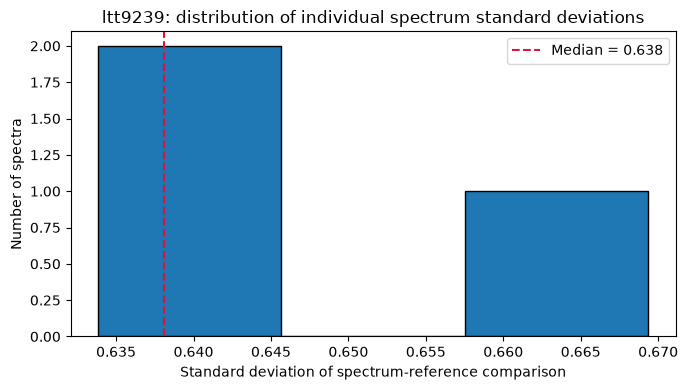

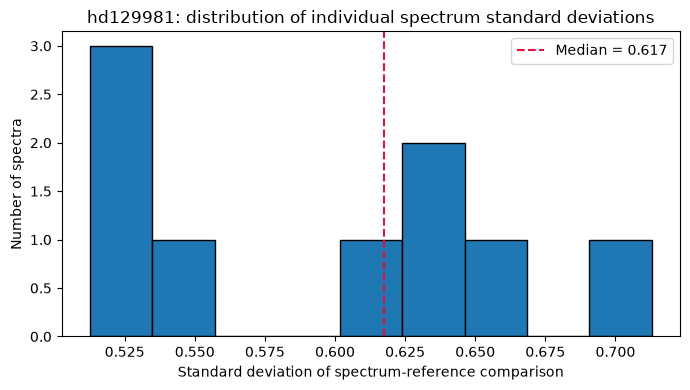

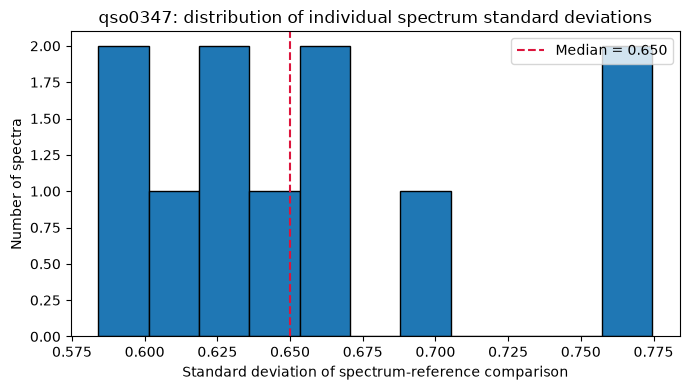

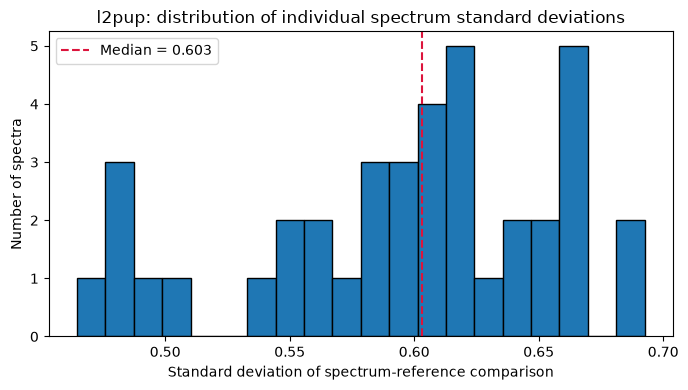

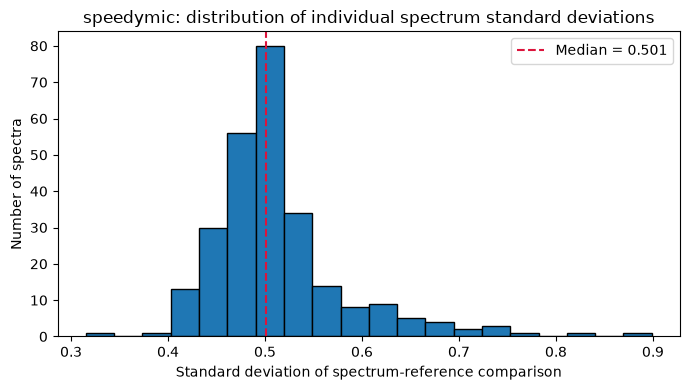

In [6]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

search_directory = Path('/home/msp25gd/ResearchProjectMSc/HR/search')
dataset_root = Path('/home/msp25gd/Downloads/res/dataset')

# Load only the ASSET class cell, without executing unrelated notebook cells.
with open(search_directory / 'asset.ipynb') as asset_file:
    asset_notebook = json.load(asset_file)
asset_source = ''.join(asset_notebook['cells'][0]['source'])
asset_source = '\n'.join(
    line for line in asset_source.splitlines()
    if not line.lstrip().startswith('%run')
)
exec(compile(asset_source, str(search_directory / 'asset.ipynb'), 'exec'))

with open(search_directory / 'param.json') as parameter_file:
    parameters = json.load(parameter_file)

std_by_star = {}
for star in selected_stars[:, 0]:
    search = ASSET(parameters=parameters, line='K')
    result = search.spec_analysis(str(dataset_root / star) + os.sep)
    if result is None:
        print(f'{star}: insufficient usable spectra')
        continue

    processed_spectra, reference_spectrum, reference_error = result
    spectrum_stds = np.array([
        np.std(
            search.snr(
                spectrum,
                reference_spectrum,
                search.spectra_err[index],
                reference_error,
            )
        )
        for index, spectrum in enumerate(processed_spectra)
    ])
    std_by_star[star] = spectrum_stds

    plt.figure(figsize=(7, 4))
    plt.hist(spectrum_stds, bins=min(20, len(spectrum_stds)), edgecolor='black')
    plt.axvline(
        np.median(spectrum_stds),
        color='crimson',
        linestyle='--',
        label=f'Median = {np.median(spectrum_stds):.3f}',
    )
    plt.xlabel('Standard deviation of spectrum-reference comparison')
    plt.ylabel('Number of spectra')
    plt.title(f'{star}: distribution of individual spectrum standard deviations')
    plt.legend()
    plt.tight_layout()
    plt.show()

Processed 50/492 groups
Processed 100/492 groups
Processed 150/492 groups
Processed 200/492 groups
Processed 250/492 groups
Processed 300/492 groups
Processed 350/492 groups
Processed 400/492 groups
Processed 450/492 groups


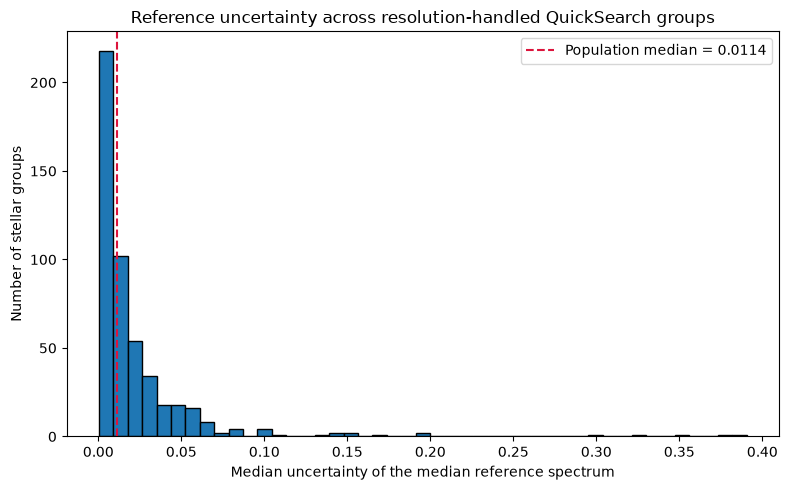

Groups plotted: 492
Groups not processed: 0


In [7]:
candidate_file = Path(
    '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2/'
    'candidates_-3.5sig_1.5cut_2width_V2_RES.npy'
)
processed_dataset = Path(
    '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates'
)
quicksearch_candidates = np.load(candidate_file, allow_pickle=True).astype(str)

reference_uncertainty_rows = []
failed_groups = []

for index, star in enumerate(quicksearch_candidates, start=1):
    search = ASSET(parameters=parameters, line='K')
    result = search.spec_analysis(str(processed_dataset / star) + os.sep)
    if result is None:
        failed_groups.append(star)
        continue

    processed_spectra, _, reference_scatter = result
    number_of_spectra = len(processed_spectra)

    # Approximate standard error of a median for normally distributed data.
    reference_uncertainty = (
        np.sqrt(np.pi / 2) * reference_scatter / np.sqrt(number_of_spectra)
    )
    search_uncertainty = reference_uncertainty[search.snr_idxrange]

    reference_uncertainty_rows.append({
        'stellar_group': star,
        'n_spectra': number_of_spectra,
        'median_reference_uncertainty': np.nanmedian(search_uncertainty),
    })

    if index % 50 == 0:
        print(f'Processed {index}/{len(quicksearch_candidates)} groups')

reference_uncertainties = pd.DataFrame(reference_uncertainty_rows)

plt.figure(figsize=(8, 5))
plt.hist(
    reference_uncertainties['median_reference_uncertainty'],
    bins='auto',
    edgecolor='black',
)
plt.axvline(
    reference_uncertainties['median_reference_uncertainty'].median(),
    color='crimson',
    linestyle='--',
    label=(
        'Population median = '
        f"{reference_uncertainties['median_reference_uncertainty'].median():.4f}"
    ),
)
plt.xlabel('Median uncertainty of the median reference spectrum')
plt.ylabel('Number of stellar groups')
plt.title('Reference uncertainty across resolution-handled QuickSearch groups')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Groups plotted: {len(reference_uncertainties)}')
print(f'Groups not processed: {len(failed_groups)}')

In [8]:
uncertainty_subsets = {
    'All QuickSearch groups': reference_uncertainties,
    'Groups with 20+ spectra': reference_uncertainties.loc[
        reference_uncertainties['n_spectra'] >= 20
    ],
    'Groups with 30+ spectra': reference_uncertainties.loc[
        reference_uncertainties['n_spectra'] >= 30
    ],
}

uncertainty_summary = pd.DataFrame([
    {
        'sample': label,
        'number_of_groups': len(subset),
        'mean_reference_uncertainty': subset[
            'median_reference_uncertainty'
        ].mean(),
        'median_reference_uncertainty': subset[
            'median_reference_uncertainty'
        ].median(),
    }
    for label, subset in uncertainty_subsets.items()
])

display(
    uncertainty_summary.style.format({
        'mean_reference_uncertainty': '{:.6f}',
        'median_reference_uncertainty': '{:.6f}',
    })
)

,sample,number_of_groups,mean_reference_uncertainty,median_reference_uncertainty
0,All QuickSearch groups,492,0.023205,0.011363
1,Groups with 20+ spectra,76,0.015675,0.008027
2,Groups with 30+ spectra,23,0.010635,0.008056


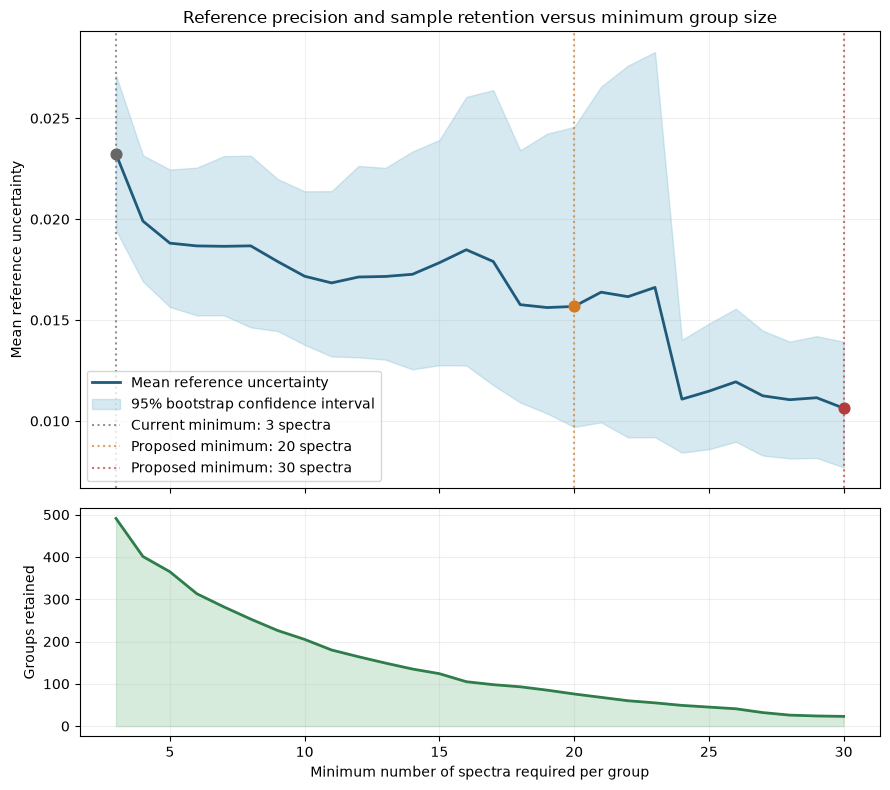

,minimum_spectra,number_of_groups,mean_reference_uncertainty,ci_lower,ci_upper,mean_reduction_percent,groups_retained_percent
0,3,491,0.023229,0.019448,0.027124,0.0%,100.0%
17,20,76,0.015675,0.009705,0.024565,32.5%,15.5%
27,30,23,0.010635,0.007698,0.013924,54.2%,4.7%


In [11]:
minimum_spectra = np.arange(3, 31)
bootstrap_iterations = 2000
rng = np.random.default_rng(42)
threshold_rows = []

for threshold in minimum_spectra:
    values = reference_uncertainties.loc[
        reference_uncertainties['n_spectra'] >= threshold,
        'median_reference_uncertainty',
    ].dropna().to_numpy()

    bootstrap_means = rng.choice(
        values,
        size=(bootstrap_iterations, len(values)),
        replace=True,
    ).mean(axis=1)

    threshold_rows.append({
        'minimum_spectra': threshold,
        'number_of_groups': len(values),
        'mean_reference_uncertainty': values.mean(),
        'ci_lower': np.percentile(bootstrap_means, 2.5),
        'ci_upper': np.percentile(bootstrap_means, 97.5),
    })

threshold_comparison = pd.DataFrame(threshold_rows)
baseline_mean = threshold_comparison.loc[
    threshold_comparison['minimum_spectra'] == 3,
    'mean_reference_uncertainty',
].iloc[0]
threshold_comparison['mean_reduction_percent'] = 100 * (
    baseline_mean - threshold_comparison['mean_reference_uncertainty']
) / baseline_mean

fig, (uncertainty_axis, count_axis) = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

uncertainty_axis.plot(
    threshold_comparison['minimum_spectra'],
    threshold_comparison['mean_reference_uncertainty'],
    color='#1f5a7a',
    linewidth=2,
    label='Mean reference uncertainty',
)
uncertainty_axis.fill_between(
    threshold_comparison['minimum_spectra'],
    threshold_comparison['ci_lower'],
    threshold_comparison['ci_upper'],
    color='#78b7d0',
    alpha=0.3,
    label='95% bootstrap confidence interval',
)

threshold_markers = [
    (3, '#666666', 'Current minimum: 3 spectra'),
    (20, '#d17a22', 'Proposed minimum: 20 spectra'),
    (30, '#b33b3b', 'Proposed minimum: 30 spectra'),
]
for threshold, color, label in threshold_markers:
    row = threshold_comparison.loc[
        threshold_comparison['minimum_spectra'] == threshold
    ].iloc[0]
    uncertainty_axis.scatter(
        threshold,
        row['mean_reference_uncertainty'],
        color=color,
        s=60,
        zorder=3,
    )
    uncertainty_axis.axvline(
        threshold,
        color=color,
        linestyle=':',
        alpha=0.7,
        label=label,
    )

uncertainty_axis.set_ylabel('Mean reference uncertainty')
uncertainty_axis.set_title(
    'Reference precision and sample retention versus minimum group size'
)
uncertainty_axis.legend()
uncertainty_axis.grid(alpha=0.2)

count_axis.plot(
    threshold_comparison['minimum_spectra'],
    threshold_comparison['number_of_groups'],
    color='#2f7d4a',
    linewidth=2,
)
count_axis.fill_between(
    threshold_comparison['minimum_spectra'],
    threshold_comparison['number_of_groups'],
    color='#8fc79f',
    alpha=0.35,
)
count_axis.set_xlabel('Minimum number of spectra required per group')
count_axis.set_ylabel('Groups retained')
count_axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

key_thresholds = threshold_comparison.loc[
    threshold_comparison['minimum_spectra'].isin([3, 20, 30])
].copy()
key_thresholds['groups_retained_percent'] = (
    100 * key_thresholds['number_of_groups'] /
    threshold_comparison.loc[
        threshold_comparison['minimum_spectra'] == 3,
        'number_of_groups',
    ].iloc[0]
)

display(
    key_thresholds.style.format({
        'mean_reference_uncertainty': '{:.6f}',
        'ci_lower': '{:.6f}',
        'ci_upper': '{:.6f}',
        'mean_reduction_percent': '{:.1f}%',
        'groups_retained_percent': '{:.1f}%',
    })
)

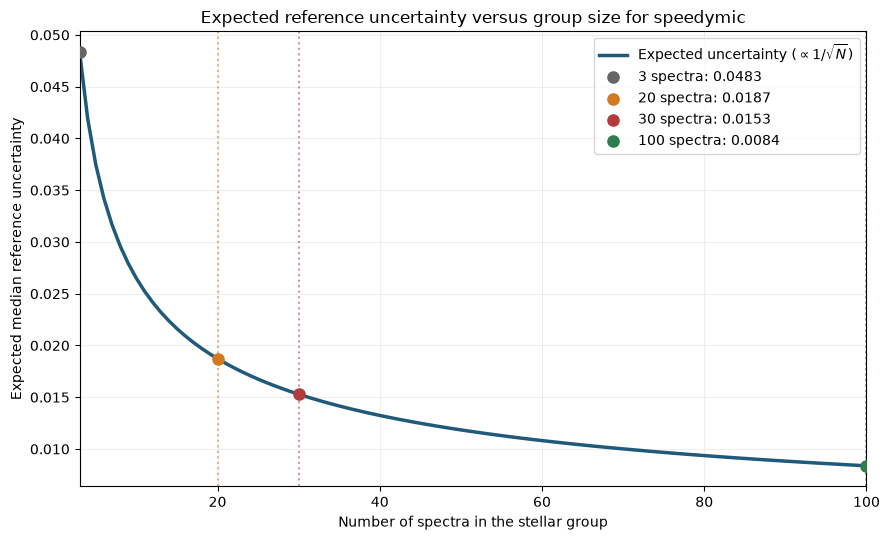

,number_of_spectra,expected_reference_uncertainty,reduction_from_3_spectra_percent
0,3,0.048348,0.0%
1,20,0.018725,61.3%
2,30,0.015289,68.4%
3,100,0.008374,82.7%


In [12]:
example_star = 'speedymic'
example_search = ASSET(parameters=parameters, line='K')
example_result = example_search.spec_analysis(
    str(processed_dataset / example_star) + os.sep
)

if example_result is None:
    raise ValueError(f'Could not process stellar group: {example_star}')

example_spectra, _, example_reference_scatter = example_result
example_search_scatter = example_reference_scatter[
    example_search.snr_idxrange
]

simulated_group_sizes = np.arange(3, 101)
median_scatter = np.nanmedian(example_search_scatter)
projected_uncertainty = (
    np.sqrt(np.pi / 2) * median_scatter / np.sqrt(simulated_group_sizes)
)

fig, uncertainty_axis = plt.subplots(figsize=(9, 5.5))
uncertainty_axis.plot(
    simulated_group_sizes,
    projected_uncertainty,
    color='#1f5a7a',
    linewidth=2.5,
    label=r'Expected uncertainty ($\propto 1/\sqrt{N}$)',
)

marker_styles = [
    (3, '#666666'),
    (20, '#d17a22'),
    (30, '#b33b3b'),
    (100, '#2f7d4a'),
]
for group_size, color in marker_styles:
    uncertainty = projected_uncertainty[group_size - 3]
    uncertainty_axis.scatter(
        group_size,
        uncertainty,
        color=color,
        s=65,
        zorder=3,
        label=f'{group_size} spectra: {uncertainty:.4f}',
    )
    uncertainty_axis.axvline(
        group_size,
        color=color,
        linestyle=':',
        alpha=0.55,
    )

uncertainty_axis.set_xlabel('Number of spectra in the stellar group')
uncertainty_axis.set_ylabel('Expected median reference uncertainty')
uncertainty_axis.set_title(
    f'Expected reference uncertainty versus group size for {example_star}'
)
uncertainty_axis.set_xlim(3, 100)
uncertainty_axis.grid(alpha=0.2)
uncertainty_axis.legend()
plt.tight_layout()
plt.show()

example_thresholds = pd.DataFrame({
    'number_of_spectra': [3, 20, 30, 100],
})
example_thresholds['expected_reference_uncertainty'] = (
    np.sqrt(np.pi / 2) * median_scatter /
    np.sqrt(example_thresholds['number_of_spectra'])
)
example_thresholds['reduction_from_3_spectra_percent'] = 100 * (
    1 - example_thresholds['expected_reference_uncertainty'] /
    example_thresholds['expected_reference_uncertainty'].iloc[0]
)

display(
    example_thresholds.style.format({
        'expected_reference_uncertainty': '{:.6f}',
        'reduction_from_3_spectra_percent': '{:.1f}%',
    })
)

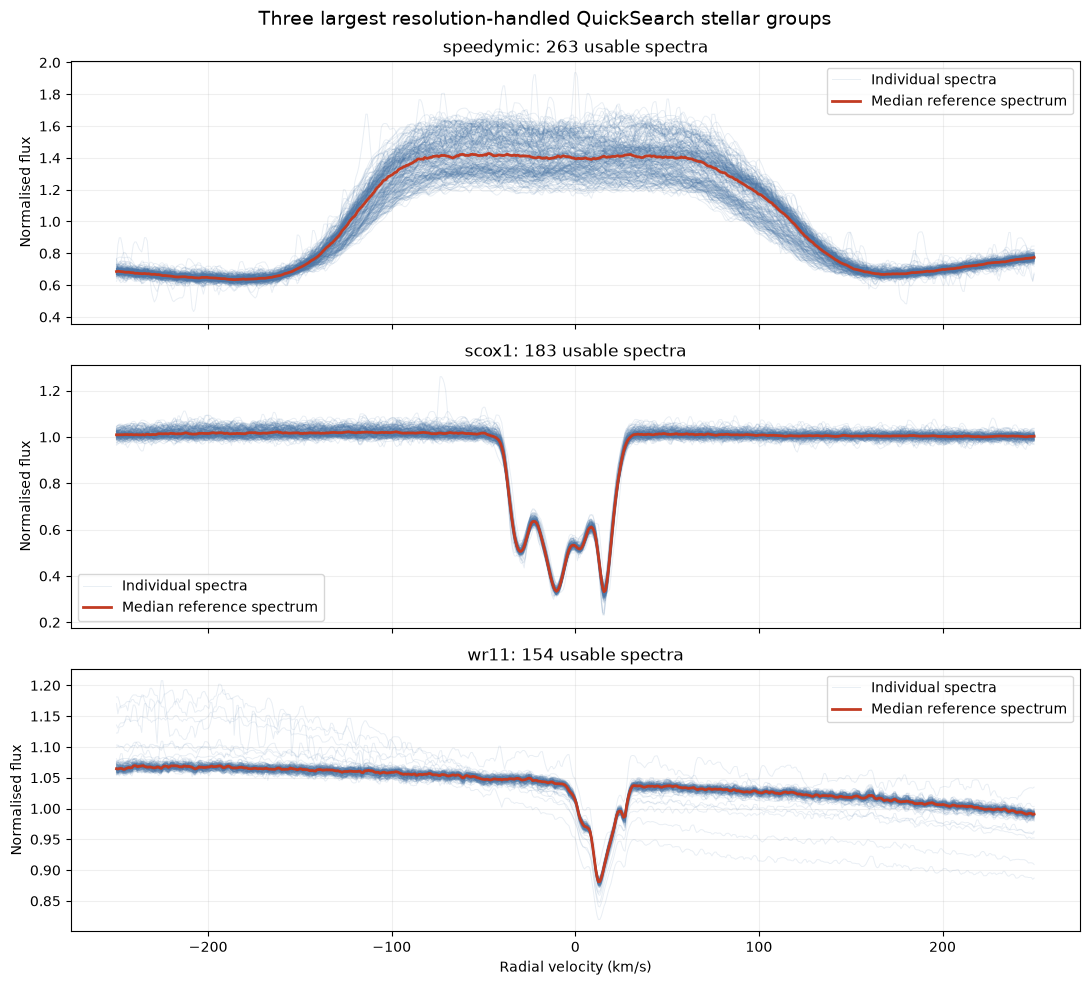

,stellar_group,n_spectra,median_reference_uncertainty
0,speedymic,263,0.005164
1,scox1,183,0.001527
2,wr11,154,0.001213


In [13]:
top_three_groups = reference_uncertainties.nlargest(3, 'n_spectra')

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for axis, group in zip(axes, top_three_groups.itertuples(index=False)):
    group_search = ASSET(parameters=parameters, line='K')
    group_result = group_search.spec_analysis(
        str(processed_dataset / group.stellar_group) + os.sep
    )
    if group_result is None:
        axis.text(0.5, 0.5, 'Insufficient usable spectra', ha='center', va='center')
        axis.set_title(group.stellar_group)
        continue

    group_spectra, group_reference, _ = group_result
    velocity_indices = group_search.snr_idxrange[0]
    velocity = group_search.radial_velocity[velocity_indices]

    for spectrum_index, spectrum in enumerate(group_spectra):
        axis.plot(
            velocity,
            spectrum[velocity_indices],
            color='#4c78a8',
            alpha=0.12,
            linewidth=0.7,
            rasterized=True,
            label='Individual spectra' if spectrum_index == 0 else None,
        )

    axis.plot(
        velocity,
        group_reference[velocity_indices],
        color='#c23b22',
        linewidth=2,
        label='Median reference spectrum',
    )
    axis.set_title(
        f'{group.stellar_group}: {len(group_spectra)} usable spectra'
    )
    axis.set_ylabel('Normalised flux')
    axis.grid(alpha=0.2)
    axis.legend(loc='best')

axes[-1].set_xlabel('Radial velocity (km/s)')
fig.suptitle(
    'Three largest resolution-handled QuickSearch stellar groups',
    fontsize=14,
)
plt.tight_layout()
plt.show()

display(
    top_three_groups[
        ['stellar_group', 'n_spectra', 'median_reference_uncertainty']
    ].reset_index(drop=True).style.format({
        'median_reference_uncertainty': '{:.6f}',
    })
)

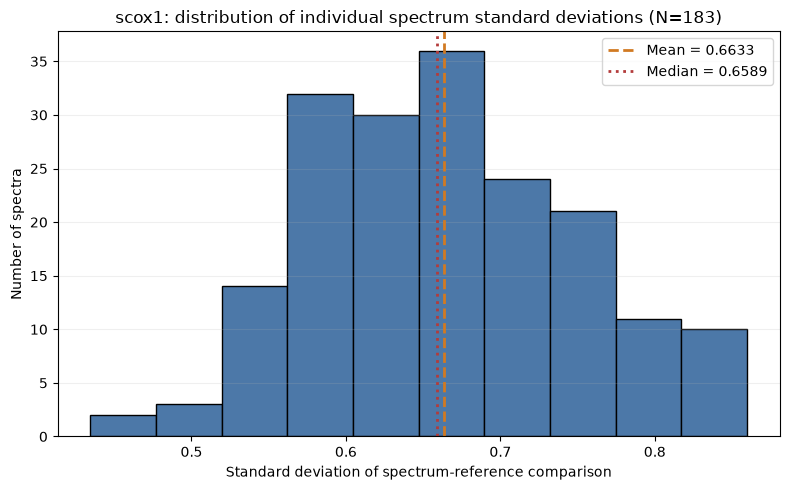

In [14]:
std_star = 'scox1'
std_search = ASSET(parameters=parameters, line='K')
std_result = std_search.spec_analysis(
    str(processed_dataset / std_star) + os.sep
)

if std_result is None:
    raise ValueError(f'Could not process stellar group: {std_star}')

std_spectra, std_reference, std_reference_error = std_result
scox1_spectrum_stds = np.array([
    np.std(
        std_search.snr(
            spectrum,
            std_reference,
            std_search.spectra_err[index],
            std_reference_error,
        )
    )
    for index, spectrum in enumerate(std_spectra)
])

plt.figure(figsize=(8, 5))
plt.hist(scox1_spectrum_stds, bins='auto', color='#4c78a8', edgecolor='black')
plt.axvline(
    scox1_spectrum_stds.mean(),
    color='#d17a22',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {scox1_spectrum_stds.mean():.4f}',
)
plt.axvline(
    np.median(scox1_spectrum_stds),
    color='#b33b3b',
    linestyle=':',
    linewidth=2,
    label=f'Median = {np.median(scox1_spectrum_stds):.4f}',
)
plt.xlabel('Standard deviation of spectrum-reference comparison')
plt.ylabel('Number of spectra')
plt.title(
    f'{std_star}: distribution of individual spectrum standard deviations '
    f'(N={len(scox1_spectrum_stds)})'
)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

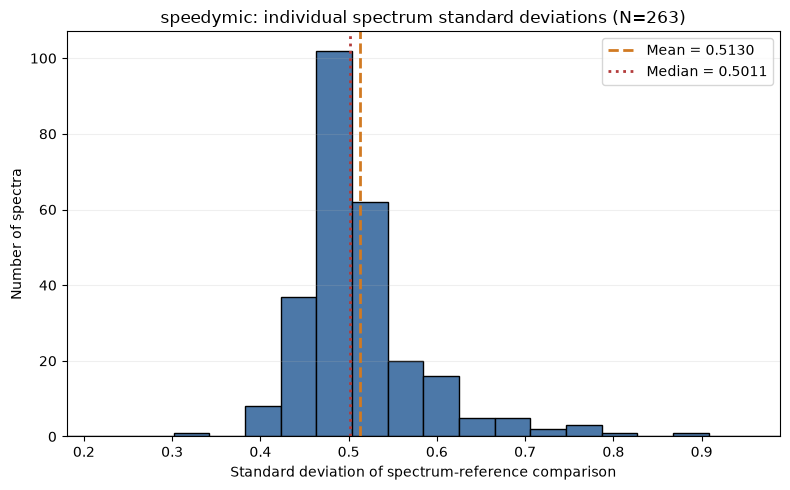

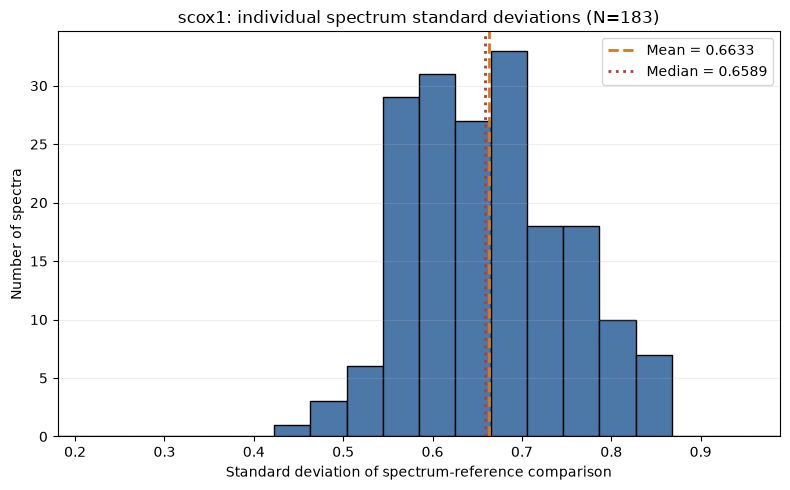

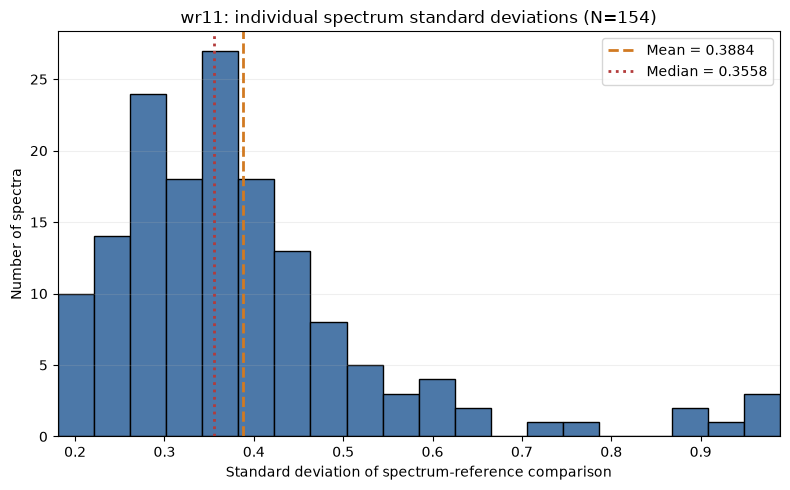

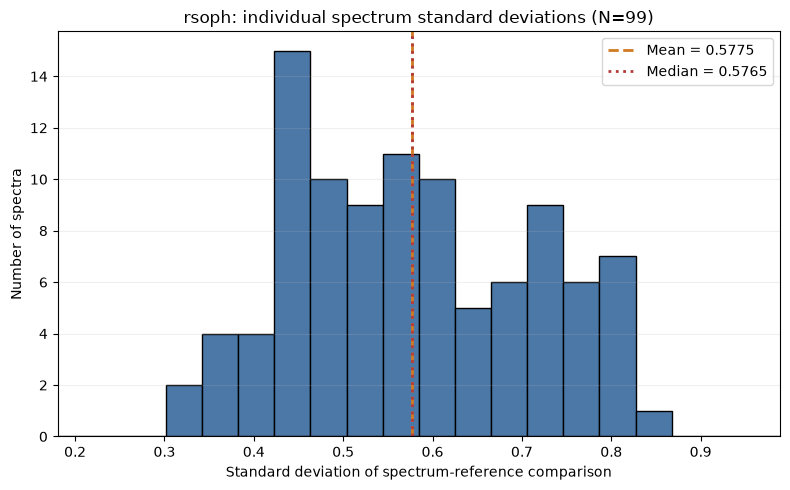

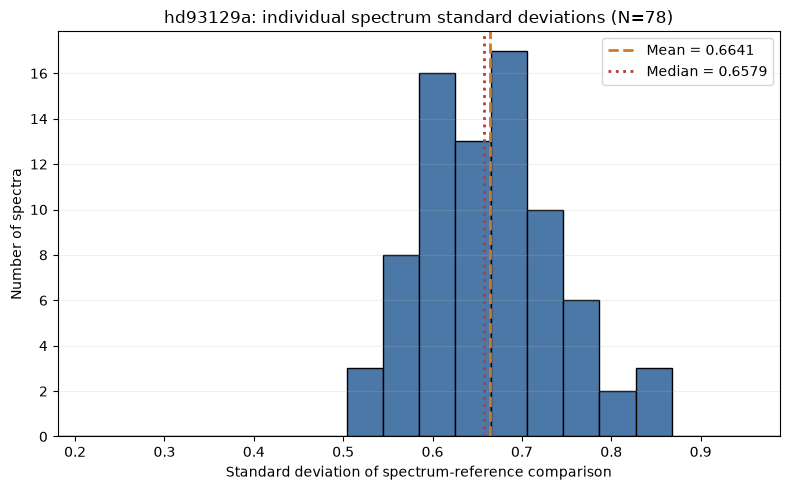

,stellar_group,n_spectra,mean_standard_deviation,median_standard_deviation
0,speedymic,263,0.5130,0.5011
1,scox1,183,0.6633,0.6589
2,wr11,154,0.3884,0.3558
3,rsoph,99,0.5775,0.5765
4,hd93129a,78,0.6641,0.6579


In [17]:
top_five_groups = reference_uncertainties.nlargest(5, 'n_spectra')
top_five_std_distributions = {}

for group in top_five_groups.itertuples(index=False):
    group_search = ASSET(parameters=parameters, line='K')
    group_result = group_search.spec_analysis(
        str(processed_dataset / group.stellar_group) + os.sep
    )
    if group_result is None:
        continue

    group_spectra, group_reference, group_reference_error = group_result
    top_five_std_distributions[group.stellar_group] = np.array([
        np.std(
            group_search.snr(
                spectrum,
                group_reference,
                group_search.spectra_err[index],
                group_reference_error,
            )
        )
        for index, spectrum in enumerate(group_spectra)
    ])

all_standard_deviations = np.concatenate(
    list(top_five_std_distributions.values())
)
shared_bin_edges = np.histogram_bin_edges(all_standard_deviations, bins='auto')
shared_x_limits = (
    all_standard_deviations.min(),
    all_standard_deviations.max(),
)

for group in top_five_groups.itertuples(index=False):
    if group.stellar_group not in top_five_std_distributions:
        continue

    standard_deviations = top_five_std_distributions[group.stellar_group]
    plt.figure(figsize=(8, 5))
    plt.hist(
        standard_deviations,
        bins=shared_bin_edges,
        color='#4c78a8',
        edgecolor='black',
    )
    plt.axvline(
        standard_deviations.mean(),
        color='#d17a22',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {standard_deviations.mean():.4f}',
    )
    plt.axvline(
        np.median(standard_deviations),
        color='#b33b3b',
        linestyle=':',
        linewidth=2,
        label=f'Median = {np.median(standard_deviations):.4f}',
    )
    plt.xlim(shared_x_limits)
    plt.xlabel('Standard deviation of spectrum-reference comparison')
    plt.ylabel('Number of spectra')
    plt.title(
        f'{group.stellar_group}: individual spectrum standard deviations '
        f'(N={len(standard_deviations)})'
    )
    plt.legend()
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

std_distribution_summary = pd.DataFrame([
    {
        'stellar_group': group.stellar_group,
        'n_spectra': len(top_five_std_distributions[group.stellar_group]),
        'mean_standard_deviation': top_five_std_distributions[
            group.stellar_group
        ].mean(),
        'median_standard_deviation': np.median(
            top_five_std_distributions[group.stellar_group]
        ),
    }
    for group in top_five_groups.itertuples(index=False)
    if group.stellar_group in top_five_std_distributions
])

display(
    std_distribution_summary.style.format({
        'mean_standard_deviation': '{:.4f}',
        'median_standard_deviation': '{:.4f}',
    })
)

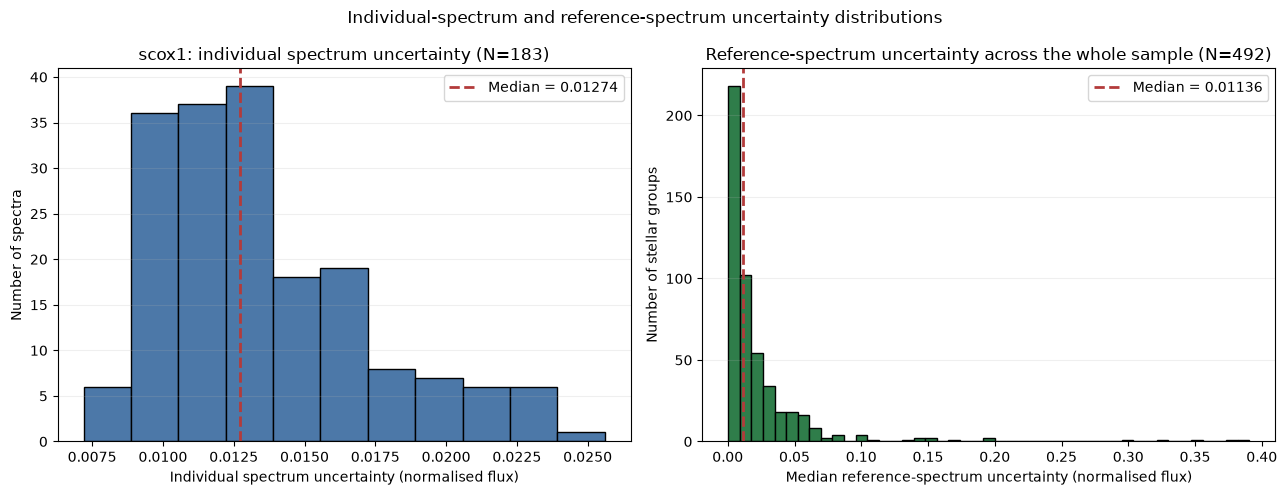

,distribution,sample_size,mean_uncertainty,median_uncertainty
0,scox1 individual spectra,183,0.013542,0.012739
1,Whole-sample reference spectra,492,0.023205,0.011363


In [18]:
# Compare per-spectrum uncertainty for scox1 with reference uncertainty across all groups.
scox1_individual_uncertainties = np.asarray(std_search.spectra_err, dtype=float)
whole_sample_reference_uncertainties = reference_uncertainties[
    'median_reference_uncertainty'
].dropna().to_numpy()

fig, (spectrum_axis, reference_axis) = plt.subplots(1, 2, figsize=(13, 5))

spectrum_axis.hist(
    scox1_individual_uncertainties,
    bins='auto',
    color='#4c78a8',
    edgecolor='black',
)
spectrum_axis.axvline(
    np.median(scox1_individual_uncertainties),
    color='#b33b3b',
    linestyle='--',
    linewidth=2,
    label=f'Median = {np.median(scox1_individual_uncertainties):.5f}',
)
spectrum_axis.set_xlabel('Individual spectrum uncertainty (normalised flux)')
spectrum_axis.set_ylabel('Number of spectra')
spectrum_axis.set_title(
    f'scox1: individual spectrum uncertainty '
    f'(N={len(scox1_individual_uncertainties)})'
)
spectrum_axis.legend()
spectrum_axis.grid(axis='y', alpha=0.2)

reference_axis.hist(
    whole_sample_reference_uncertainties,
    bins='auto',
    color='#2f7d4a',
    edgecolor='black',
)
reference_axis.axvline(
    np.median(whole_sample_reference_uncertainties),
    color='#b33b3b',
    linestyle='--',
    linewidth=2,
    label=f'Median = {np.median(whole_sample_reference_uncertainties):.5f}',
)
reference_axis.set_xlabel('Median reference-spectrum uncertainty (normalised flux)')
reference_axis.set_ylabel('Number of stellar groups')
reference_axis.set_title(
    'Reference-spectrum uncertainty across the whole sample '
    f'(N={len(whole_sample_reference_uncertainties)})'
)
reference_axis.legend()
reference_axis.grid(axis='y', alpha=0.2)

fig.suptitle('Individual-spectrum and reference-spectrum uncertainty distributions')
plt.tight_layout()
plt.show()

uncertainty_distribution_summary = pd.DataFrame([
    {
        'distribution': 'scox1 individual spectra',
        'sample_size': len(scox1_individual_uncertainties),
        'mean_uncertainty': np.mean(scox1_individual_uncertainties),
        'median_uncertainty': np.median(scox1_individual_uncertainties),
    },
    {
        'distribution': 'Whole-sample reference spectra',
        'sample_size': len(whole_sample_reference_uncertainties),
        'mean_uncertainty': np.mean(whole_sample_reference_uncertainties),
        'median_uncertainty': np.median(whole_sample_reference_uncertainties),
    },
])

display(
    uncertainty_distribution_summary.style.format({
        'mean_uncertainty': '{:.6f}',
        'median_uncertainty': '{:.6f}',
    })
)